

# Assignment 1: Decision Trees
### COMM 4259 <br> <i>Foundations of Machine Learning and AI with Python</i>


© Jingjing Li- Ask for permission for using/quoting: jingjing.li@virginia.edu


# Description

This assignment has 3 sections and is to be completed individually. Collaborations with peers or seeking assistance from unauthorized sources will be considered a breach of the Honor Code.

| Section | What | Weight | Generative AI |
|---|---|---|---|
| 1 | Evaluating the impact of parameter settings on decision tree models | 30% | Not allowed |
| 2 | Wine quality prediction | 60% | Not allowed |
| 3 | GitHub record of your work | 10% | Not allowed |

- **Restricted resources**: <font color='red'>DO NOT use any generative AI tools in any part of this assignment.</font>
- **Recommended resources**: the Lab 4 notebooks (Parts 1 and 2), the Predictive Analytics lecture slides, and your notes.

## Submission
- **Canvas**: upload this notebook, with your GitHub repository link filled in at the end of Section 3.
- **GitHub**: push your work to your `comm4259-work` repository before the deadline (see the GitHub section).

## Before you start: put this assignment in your course repository

Do this first, before Section 1, so your work is in GitHub from the start and you do not have to remember it at the end.

1. Unzip `assignment_01.zip` into your `comm4259-work` folder, so this notebook and the data sit in `comm4259-work/assignment_01/`.
2. In VS Code, open the `comm4259-work` folder itself (File > Open Folder), then open this notebook from the Explorer panel.
3. In the VS Code terminal (Terminal > New Terminal), make your first commit now:
   ```
   git add .
   git commit -m "Assignment 1: start"
   git push
   ```
4. Repeat the three commands after each section. Section 3 explains what we look for in your repository.


# Section 1: Evaluating the Impact of Parameter Settings on Decision Tree Models (30%)
## Objective
- Create Decision Tree models on the MovieReviews_Train.csv and MovieReviews_Test.csv files.
- Assess the impact of the **min_impurity_decrease** and **max_depth parameters** on **tree structure**, **training accuracy**, and **test accuracy** of the Decision Tree model. 

## Requirements
- Use “Polarity” as the target class label. 
- Run each Decision Tree using the **entropy** criterion and **random_state = 1**, with default settings for all other parameters (i.e, no need to set the values for other parameters for DecisionTreeClassifier). The four parameter combinations are:
    - min_impurity_decrease = 0.002, max_depth = 4
    - min_impurity_decrease = 0.008, max_depth = 4
    - min_impurity_decrease = 0.002, max_depth = 6
    - min_impurity_decrease = 0.008, max_depth = 6
- Display the trees using **plot_tree** in the notebook, print the **number of nodes (use the tree_.node_count)**, and save each tree as an image (tree1.pdf, tree2.pdf, tree3.pdf, and tree4.pdf).
- Print training and testing accuracies for each setting.
- Answer the questions at the end of this section.

<font color = 'red'>**Notes:**</font>
- You can refer to Lab 4 **Default Parameter Setting (Putting all the codes together)** to accomplish this task.  
- Do not use the train_test_split function. The data is already split into **MovieReviews_Train.csv** and **MovieReviews_Test.csv**, so read each file and separate the features from the label, like this (the label column is `Polarity`):
  ```python
  import pandas as pd
  train = pd.read_csv("MovieReviews_Train.csv")
  test = pd.read_csv("MovieReviews_Test.csv")
  X_train = train.drop(columns="Polarity")
  y_train = train["Polarity"]
  X_test = test.drop(columns="Polarity")
  y_test = test["Polarity"]
  ```
  Fit each tree on `X_train, y_train`, then compute accuracy on the training data and on `X_test, y_test`. Only the training data is used for tree visualization.
- The codes are supposed to answers the specific questions above. DO NOT copy all the codes from the lab. Placing excessive amount of unnecessary codes below will receive a point deduction.
- It’s okay if the tree details aren’t clearly visible; our primary focus is observing the differences in tree sizes. 

## Find the scikit-learn version
This assignment works with scikit-learn 1.3 or newer. If your version is older, reinstall Anaconda rather than upgrading with pip.

In [12]:
import sklearn
print(sklearn.__version__)

1.9.1


## Import libraries

In [13]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.tree import export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Ignore useless warnings
import warnings
warnings.simplefilter("ignore", UserWarning)

## Data Preparation

In [14]:
train = pd.read_csv("MovieReviews_Train.csv")
test = pd.read_csv("MovieReviews_Test.csv")
X_train = train.drop(columns="Polarity")
y_train = train["Polarity"]
X_test = test.drop(columns="Polarity")
y_test = test["Polarity"]

In [15]:
train.head()

,BAD,WORST,AWFUL,STUPID,MESS,BORING,WASTE,WASTED,RIDICULOUS,OUTSTANDING,...,GOT_TO_BE,AT_LEAST_HE,OF_THE_BAD,A_REALLY_BAD,THE_WORST_FILMS,YOUVE_SEEN_THE,FILM_IS_A,IVE_EVER_SEEN,DELIVERS,Polarity
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,positive
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,positive
2,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,positive
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,positive
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,positive


In [16]:
test.head()

,BAD,WORST,AWFUL,STUPID,MESS,BORING,WASTE,WASTED,RIDICULOUS,OUTSTANDING,...,GOT_TO_BE,AT_LEAST_HE,OF_THE_BAD,A_REALLY_BAD,THE_WORST_FILMS,YOUVE_SEEN_THE,FILM_IS_A,IVE_EVER_SEEN,DELIVERS,Polarity
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,positive
1,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,negative
2,0,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,positive
3,0,0,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,negative
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,negative


In [17]:
train.Polarity.value_counts()

Polarity
positive    543
negative    529
Name: count, dtype: int64

In [18]:
train.Polarity.describe()

count         1072
unique           2
top       positive
freq           543
Name: Polarity, dtype: object

## Define Functions (if needed)

In [19]:
fnames = list(X_train.columns)
print(fnames)
cnames = list(y_train.unique())
print(cnames)

['BAD', 'WORST', 'AWFUL', 'STUPID', 'MESS', 'BORING', 'WASTE', 'WASTED', 'RIDICULOUS', 'OUTSTANDING', 'MEMORABLE', 'TERRIFIC', 'WONDERFULLY', 'TERRIBLE', 'WONDERFUL', 'SUPPOSED', 'POORLY', 'FINEST', 'SCRIPT', 'PERFORMANCES', 'LIFE', 'PERFECTLY', 'EXCELLENT', 'DULL', 'LAME', 'GREAT', 'PERFECT', 'PLOT', 'EFFECTIVE', 'LUDICROUS', 'SUBTLE', 'WORSE', 'INEPT', 'ERA', 'UNFUNNY', 'BRILLIANT', 'TRUE', 'FAMILY', 'POINTLESS', 'SOLID', 'IDIOTIC', 'STUPIDITY', 'FAILS', 'TALE', 'WORLD', 'POOR', 'INSULTING', 'BEAUTIFULLY', 'PORTRAYAL', 'WITTY', 'PAINFULLY', 'HILARIOUS', 'ANGER', 'PERIOD', 'DESERVES', 'STRONG', 'FANTASTIC', 'FLAWS', 'BREATHTAKING', 'AMERICA', 'LAUGHABLE', 'DUMB', 'DELIGHTFUL', 'AMERICAN', 'CAPTURES', 'BLAND', 'PREDICTABLE', 'PERFORMANCE', 'DAMON', 'BORE', 'FORGOT', 'REALISTIC', 'SUPERB', 'FLAWLESS', 'REASON', 'HISTORY', 'WHATSOEVER', 'HUDSON', 'SEAGAL', 'DEGENERATES', 'OSCAR', 'RELIGION', 'MARVELOUS', 'SLOPPY', 'GUESS', 'UNLIKE', 'YOUNG', 'DREAD', 'ANIMATION', 'NONSENSE', 'PORTRAYED',

In [20]:
def viz_tree_fig(dt, fnames, cnames, figname=None, show=True):
    fig, ax = plt.subplots(figsize=(10, 10))
    plot_tree(
        dt,
        feature_names=fnames,
        class_names=[str(c) for c in cnames],  # ensure strings
        rounded=True,
        filled=True,
        ax=ax
    )
    fig.tight_layout()

    if figname:  # save if a filename is provided
        fig.savefig(figname, bbox_inches="tight")

    if show:     # display in the notebook
        display(fig)

    plt.close(fig)  

The four parameter combinations are:

    - min_impurity_decrease = 0.002, max_depth = 4
    - min_impurity_decrease = 0.008, max_depth = 4
    - min_impurity_decrease = 0.002, max_depth = 6
    - min_impurity_decrease = 0.008, max_depth = 6
  
- Display the trees using **plot_tree** in the notebook, print the **number of nodes (use the tree_.node_count)**, and save each tree as an image (tree1.pdf, tree2.pdf, tree3.pdf, and tree4.pdf).

## Decision tree 1 (Tree visualization; training and testing accuracies)

In [46]:
dt = DecisionTreeClassifier(max_depth=4, min_impurity_decrease=0.002, criterion="entropy", random_state=1)
dt.fit(X_train, y_train)
print(dt.tree_.node_count)
dt.accuracy = accuracy_score(y_test, dt.predict(X_test))
print(f"Accuracy of dt: {dt.accuracy:.4f}")

21
Accuracy of dt: 0.6212


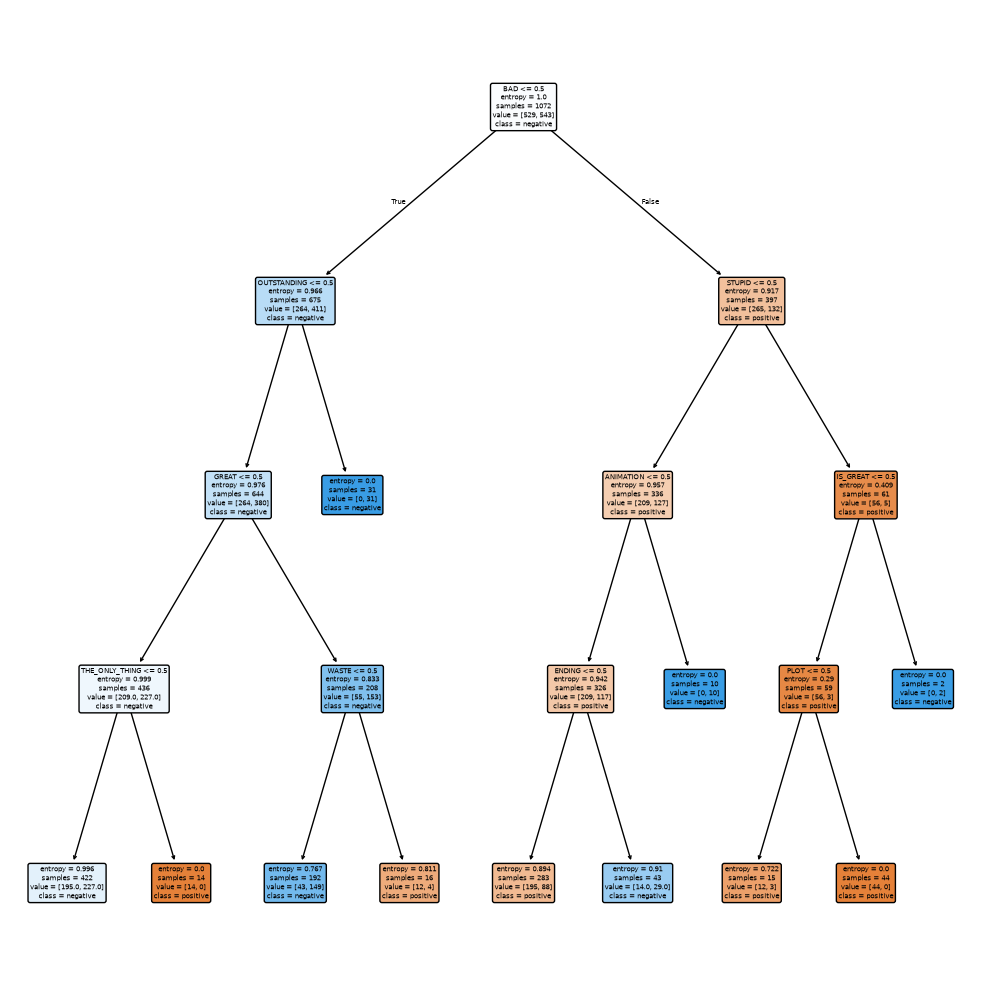

In [36]:
viz_tree_fig(dt, fnames, cnames, figname="tree1.pdf", show=True)

## Decision tree 2 (Tree visualization; training and testing accuracies)

In [47]:
dt2 = DecisionTreeClassifier(max_depth=4, min_impurity_decrease=0.008, criterion="entropy", random_state=1)
dt2.fit(X_train, y_train)
print(dt2.tree_.node_count)
dt2.accuracy = accuracy_score(y_test, dt2.predict(X_test))
print(f"Accuracy of dt2: {dt2.accuracy:.4f}")

17
Accuracy of dt2: 0.6231


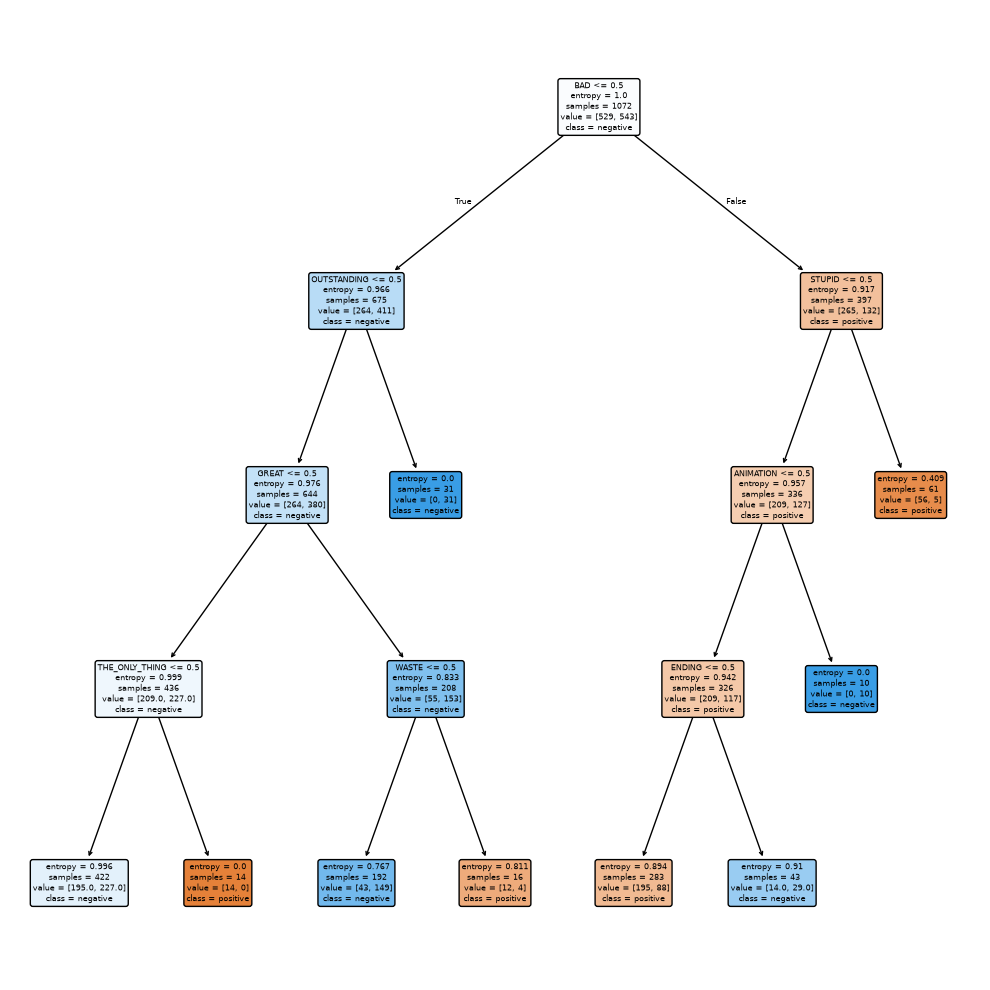

In [48]:
viz_tree_fig(dt2, fnames, cnames, figname="tree2.pdf", show=True)

## Decision tree 3 (Tree visualization; training and testing accuracies)

In [49]:
dt3 = DecisionTreeClassifier(max_depth=6, min_impurity_decrease=0.002, criterion="entropy", random_state=1)
dt3.fit(X_train, y_train)
print(dt3.tree_.node_count)
dt3.accuracy = accuracy_score(y_test, dt3.predict(X_test))
print(f"Accuracy of dt3: {dt3.accuracy:.4f}")

51
Accuracy of dt3: 0.6288


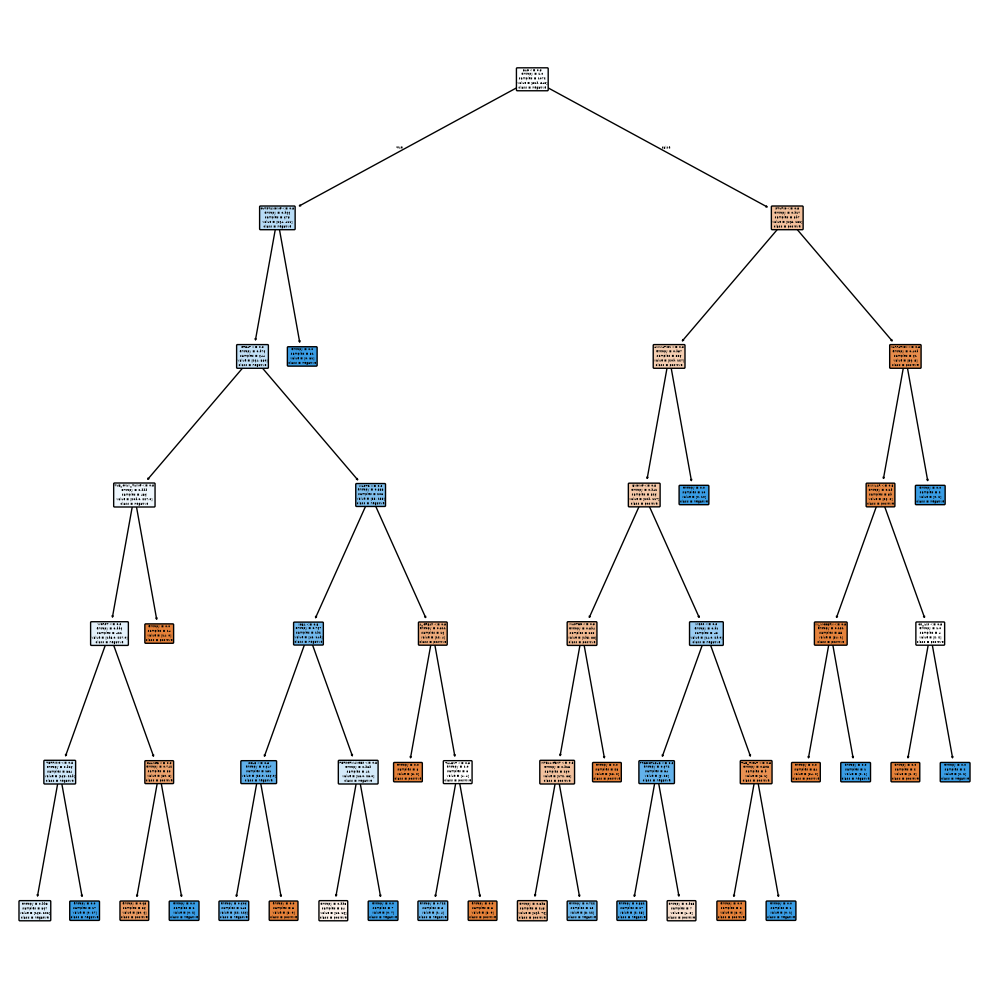

In [50]:
viz_tree_fig(dt3, fnames, cnames, figname="tree3.pdf", show=True)

## Decision tree 4 (Tree visualization; training and testing accuracies)

In [51]:
dt4 = DecisionTreeClassifier(max_depth=6, min_impurity_decrease=0.008, criterion="entropy", random_state=1)
dt4.fit(X_train, y_train)
print(dt4.tree_.node_count)
dt4.accuracy = accuracy_score(y_test, dt4.predict(X_test))
print(f"Accuracy of dt4: {dt4.accuracy:.4f}")

29
Accuracy of dt4: 0.6402


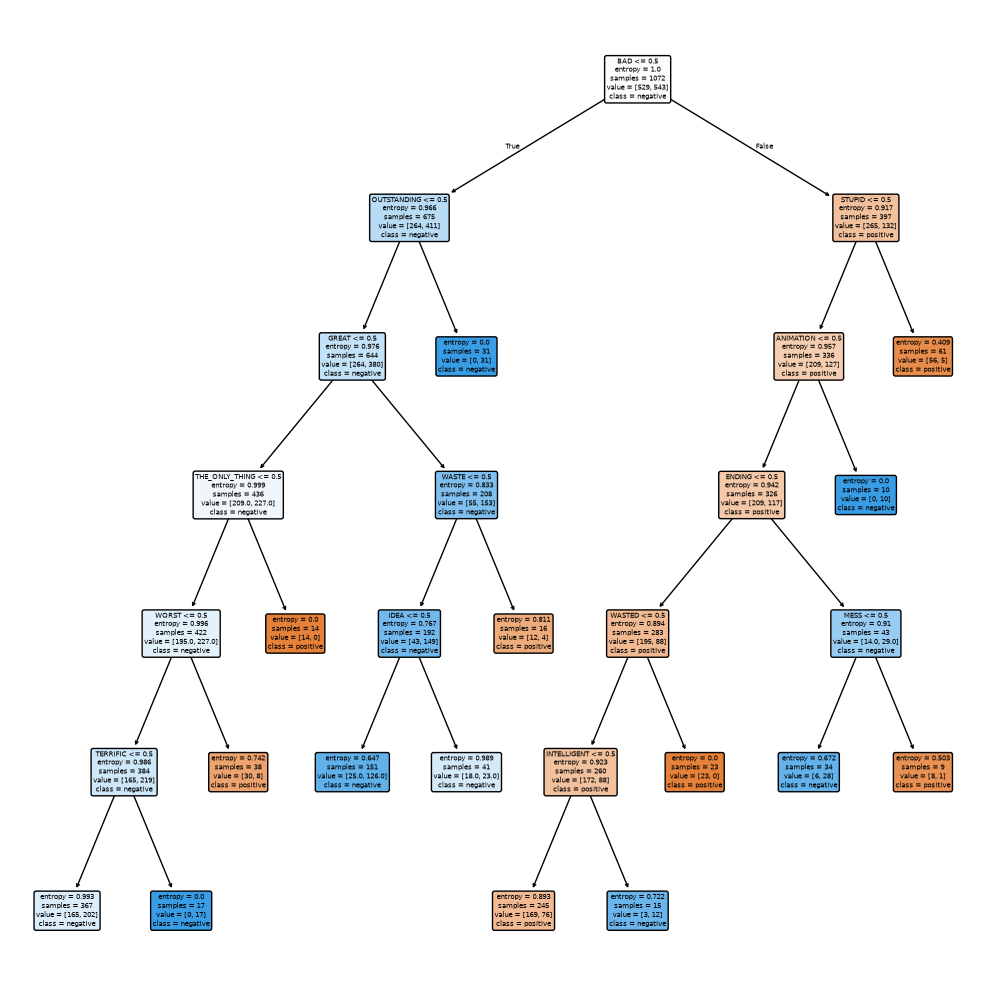

In [52]:
viz_tree_fig(dt4, fnames, cnames, figname="tree4.pdf", show=True)

## Answer the Section 1 Questions

1. Based on the above results, how do min_impurity_decrease and maximal depth impact the structure and accuracies of the Decision Trees? 
2. Which of the four settings is most likely to over-fit to the training data?   
3. Based on the training and testing accuracy, what trend do you notice with respect to differences on the training versus testing accuracies?  

Type your answer below:

1. min_impurity_decrease makes the strong branches grow longer and the weaker branches terminate earlier. So the longest branches are the strongest and the shortest ones are weaker. Maximal depth makes the tree grow larger and have more levels. 

- The tree with depth = 6 and the highest min_impurity_decrease was the most accurate. 

2. The one with the greatest depth and min_impurity (number 4)

3. Generally training accuracies are higher

# Section 2: Wine Quality Prediction (60%)

## Background
- A winemaker seeks to predict the perceived quality of their wine based on its ingredients.
- The winemaker has provided training (WineQuality_Train.csv) and testing datasets (WineQuality_Test.csv).
- Each dataset comprises 11 independent variables and one target variable labeled “Quality,” which was initially rated on a 1-10 scale through customer surveys but has been modified for this task to be a binary classification: “Good” or “Poor.”
- A model’s predictive performance is evaluated based on the accuracy of the testing data.

## Requirements
- Utilize the DecisionTreeClassifer as introduced in our lab. Do not use other models.
- Do not modify the testing data. Read **WineQuality_Train.csv** and **WineQuality_Test.csv** the same way as in Section 1; the label column in these files is spelled `quality` (lowercase).
- Use the **entropy** criterion and set **random_state = 1**.
- <font color = 'red'>You are limited to adjusting **only two model parameters**: **min_impurity_decrease** and **max_depth**, with default settings for all other parameters.</font>
- **A maximum of five parameter combinations** is permitted (i.e., five rows in the spreadsheet deliverable). <font color = 'red'>**Manually set parameters based on your observations of the training and testing accuracies in the last parameter combination. You should not use "for loops" or "while loops," any automation functions for parameter tuning.**</font>

- DO NOT use the train_test_split as the data is pre-split. Train a model on **WineQuality_Train.csv** and test on **WineQuarlitey_Test.csv**, i.e. use pd.read_csv two times to read the training and testing data, respectively.


## Imports & Data Ingestion

In [3]:
import pandas as pd
import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load datasets
train_path = '/Users/bzcruz/Braden/School/comm4259-work/assignment_01/WineQuality_Train.csv'
test_path = '/Users/bzcruz/Braden/School/comm4259-work/assignment_01/WineQuality_Test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Separate features and target (target column is lowercase 'quality')
X_train = train_df.drop(columns=['quality'])
y_train = train_df['quality']

X_test = test_df.drop(columns=['quality'])
y_test = test_df['quality']

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (1200, 11)
Testing data shape: (1500, 11)


## Helper Functions & Model Creation

## Deliverable 1: 
- One paragraph discussion about the parameter settings (min_impurity_decrease and max_depth) of your best model and how you find the best test accuracy.

Type your answers below

## Deliverable 2: 
- Python codes with the parameter setting for your best model in terms of testing accuracy. Use get_params() function to print all the parameters for your best model.

## Deliverable 3: 
- A table with one row per model run (at most five), giving the date and time of the run, the parameter setting, the training and testing accuracies, and the run time. Fill in the markdown table below.

Double-click this cell to edit it, type your numbers into the empty cells of the table, then run the cell to render it. The first row shows the format; replace it with your own first run. If you prefer, build the rows with [Markdown Tables Generator](https://www.tablesgenerator.com/markdown_tables) and paste them here.

| DateTime | min_impurity_decrease | max_depth | training_accuracy | testing_accuracy |run time |
|----------|-----------------------|-----------|-------------------|------------------|------------------|
| 09-28-2026, 9:30 am|             |           |                 |                  |  < 1 min
|          |                       |           |                   |                  |                 |
|          |                       |           |                   |                  |                  |
|          |                       |           |                   |                  |                  |
|          |                       |           |                   |                  |                  |

# Section 3: GitHub Record of Your Work (10%)

Keep this assignment in your `comm4259-work` repository, the same one you push labs to.

1. **Folder.** Unzip the assignment into `comm4259-work/assignment_01/`.
2. **Commit as you go.** Make **at least three commits** for this assignment, spread over your work (for example after each section), each with a message that says what changed. Run the commands from `comm4259-work`:
   ```
   git add .
   git commit -m "Assignment 1: finished Section 1"
   git push
   ```
3. **Push before the deadline.** Your last commit must be pushed before the Canvas due date. Commit times are checked.
4. **Give the teaching team access.** Your repository is private, so add the instructor and both TAs as collaborators. On github.com, open your repository, choose **Settings > Collaborators > Add people**, and add `analyticsli`, `zayliet` and `jisungl`. Or run these three commands in the terminal from `comm4259-work`:
   ```
   gh api -X PUT "repos/{owner}/{repo}/collaborators/analyticsli" -f permission=pull
   gh api -X PUT "repos/{owner}/{repo}/collaborators/zayliet" -f permission=pull
   gh api -X PUT "repos/{owner}/{repo}/collaborators/jisungl" -f permission=pull
   ```
   You only need to do this once, in Assignment 1.
5. **Paste your repository link** on the line below.

**GitHub repository link:** *(paste it here, for example https://github.com/your-username/comm4259-work)*

| Item | Points |
|---|---|
| At least three commits for this assignment, spread over the work, pushed before the deadline | 5 |
| Folders as described above, with the teaching team able to see the repository | 5 |

## Grading Criteria
- Sections 1 and 2 are graded on the correctness of your code and the completeness of your answers.
- Section 3 is graded with the checklist in that section.